# MSAI Computer Vision, Seminar 02: Morphology and classical segmentation

Based on [GeorgBell material](https://github.com/GeorgBell/ComputerVisionCourse/blob/main/Week_4/Seminar/%D0%9F4_%D0%9C%D0%BE%D1%80%D1%84%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%8F_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F.ipynb)

In [7]:
from collections import deque
from math import exp, sqrt

import cv2
import imutils
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
from skimage import color, data, feature, img_as_float, io
from skimage.color import label2rgb, rgb2hsv
from skimage.draw import circle_perimeter, ellipse_perimeter
from skimage.feature import canny, peak_local_max
from skimage.filters import threshold_otsu, try_all_threshold
from skimage.measure import label, regionprops
from skimage.morphology import (
    black_tophat,
    closing,
    convex_hull_image,
    dilation,
    disk,
    erosion,
    medial_axis,
    opening,
    skeletonize,
    square,
    thin,
    white_tophat,
)
from skimage.segmentation import clear_border, watershed
from skimage.transform import hough_circle, hough_circle_peaks, hough_ellipse
from skimage.util import img_as_ubyte, invert

## Color spaces
### RGB to HSV

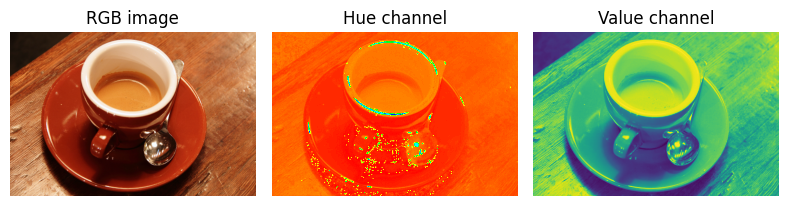

In [8]:
rgb_img = data.coffee()
hsv_img = rgb2hsv(rgb_img)
hue_img = hsv_img[:, :, 0]
value_img = hsv_img[:, :, 2]

fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(8, 2))

ax0.imshow(rgb_img)
ax0.set_title("RGB image")
ax0.axis("off")
ax1.imshow(hue_img, cmap="hsv")
ax1.set_title("Hue channel")
ax1.axis("off")
ax2.imshow(value_img)
ax2.set_title("Value channel")
ax2.axis("off")

fig.tight_layout()

Let's make segmentation!

In [9]:
hue_threshold = 0.04
binary_img = hue_img > hue_threshold

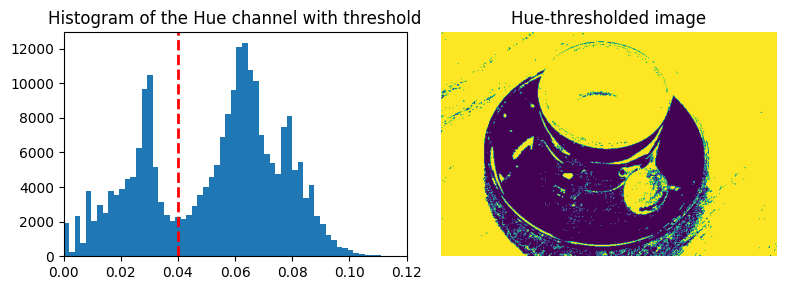

In [10]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

ax0.hist(hue_img.ravel(), 512)
ax0.set_title("Histogram of the Hue channel with threshold")
ax0.axvline(x=hue_threshold, color="r", linestyle="dashed", linewidth=2)
ax0.set_xbound(0, 0.12)
ax1.imshow(binary_img)
ax1.set_title("Hue-thresholded image")
ax1.axis("off")

fig.tight_layout()

Also we threshold value channel

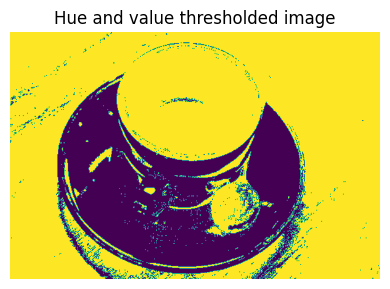

In [11]:
fig, ax0 = plt.subplots(figsize=(4, 3))

value_threshold = 0.10
binary_img = (hue_img > hue_threshold) | (value_img < value_threshold)

ax0.imshow(binary_img)
ax0.set_title("Hue and value thresholded image")
ax0.axis("off")

fig.tight_layout()
plt.show()

In [12]:
flags = [i for i in dir(cv2) if i.startswith("COLOR_")]
print(flags)

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

### Images binarisation

[Otsu filter](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.threshold_otsu) aka k-means on intensity histogram

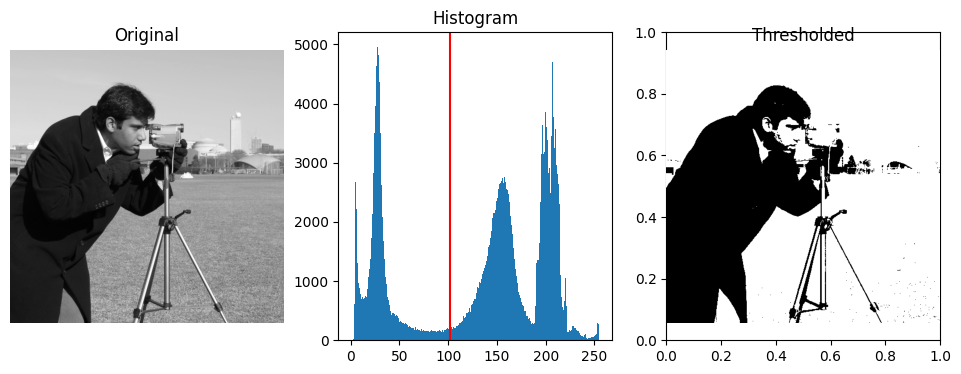

In [13]:
image = data.camera()
thresh = threshold_otsu(image)
binary = image > thresh

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title("Histogram")
ax[1].axvline(thresh, color="r")

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title("Thresholded")
ax[2].axis("off")

plt.show()

Automatic function to try [all thresholds](https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding_guide.html)

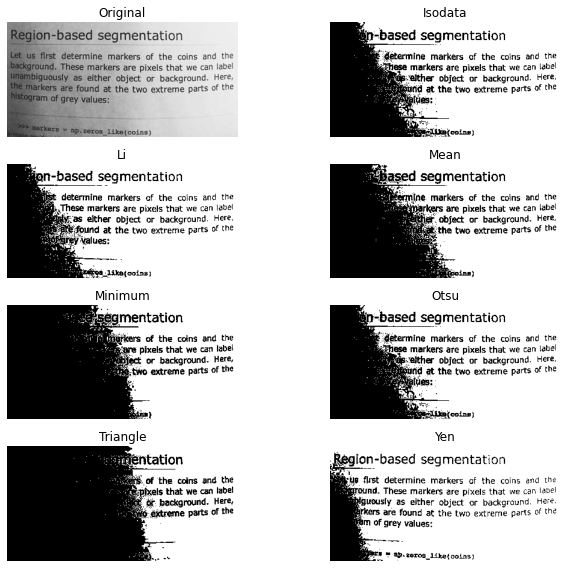

In [9]:
img = data.page()
fig, ax = try_all_threshold(img, figsize=(10, 8), verbose=False)
plt.show()

## Morphology

[OpenCV docs](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)

[skimage docs](https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html)

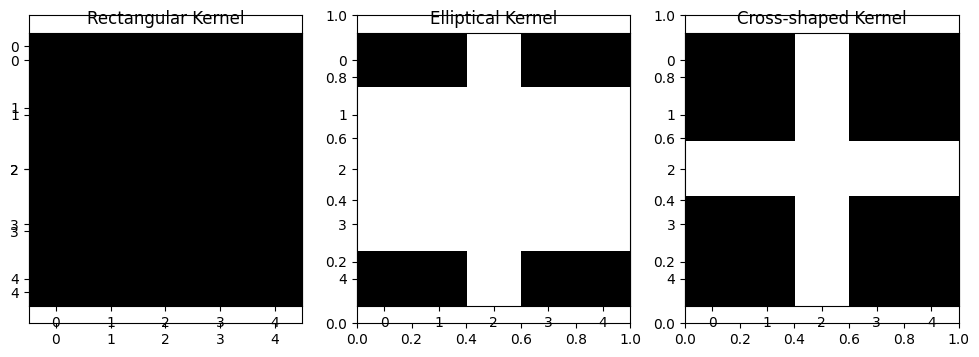

In [14]:
# Rectangular Kernel
kern_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
# Elliptical Kernel
kern_ellip = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
# Cross-shaped Kernel
kern_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1, sharex=ax[0], sharey=ax[0])
ax[1] = plt.subplot(1, 3, 2, sharex=ax[0], sharey=ax[0])
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(kern_rect, cmap=plt.cm.gray)
ax[0].set_title("Rectangular Kernel")

ax[1].imshow(kern_ellip, cmap=plt.cm.gray)
ax[1].set_title("Elliptical Kernel")

ax[2].imshow(kern_cross, cmap=plt.cm.gray)
ax[2].set_title("Cross-shaped Kernel")

plt.show()

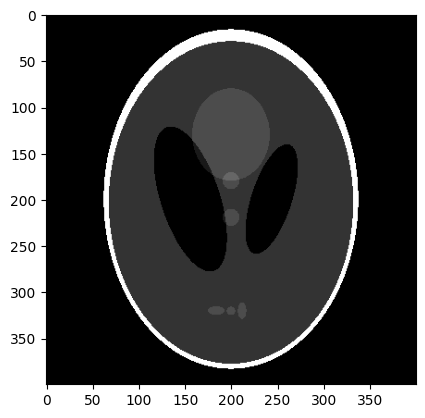

In [15]:
orig_phantom = img_as_ubyte(data.shepp_logan_phantom())
fig, ax = plt.subplots()
ax.imshow(orig_phantom, cmap=plt.cm.gray)

In [16]:
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 6), sharex=True, sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title("original")
    ax1.axis("off")
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis("off")

### Erosion

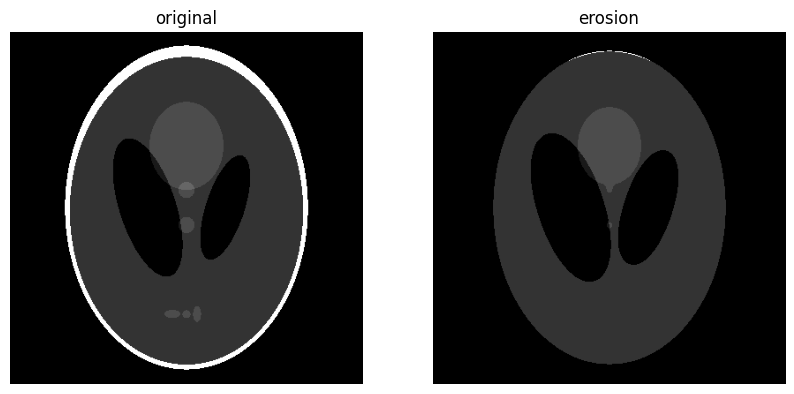

In [17]:
selem = disk(6)
eroded = erosion(orig_phantom, selem)
plot_comparison(orig_phantom, eroded, "erosion")

### Dilation

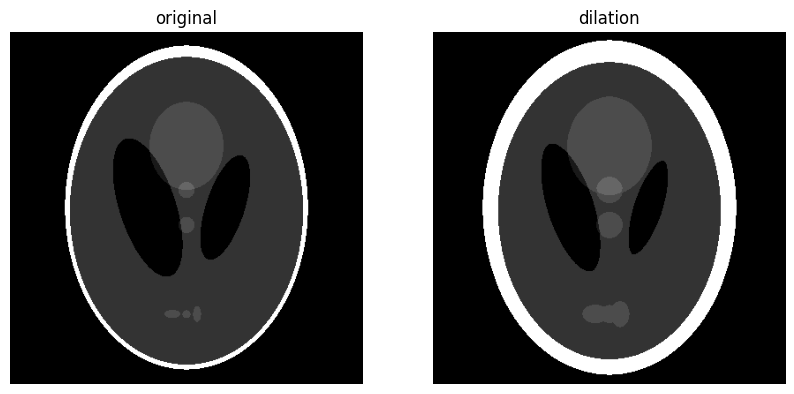

In [18]:
dilated = dilation(orig_phantom, selem)
plot_comparison(orig_phantom, dilated, "dilation")

### Opening

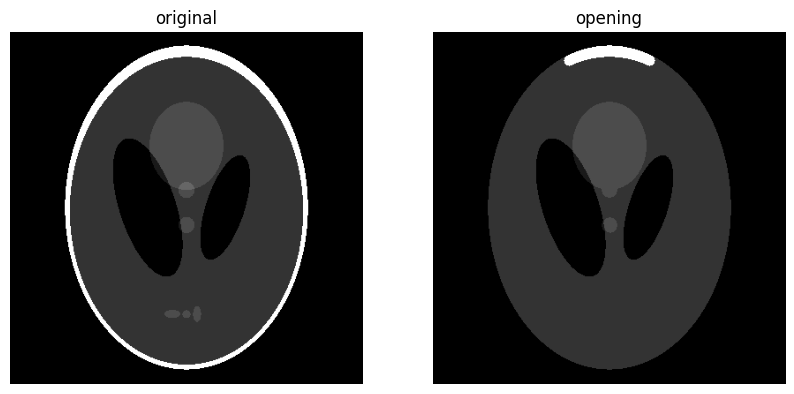

In [19]:
opened = opening(orig_phantom, selem)
plot_comparison(orig_phantom, opened, "opening")

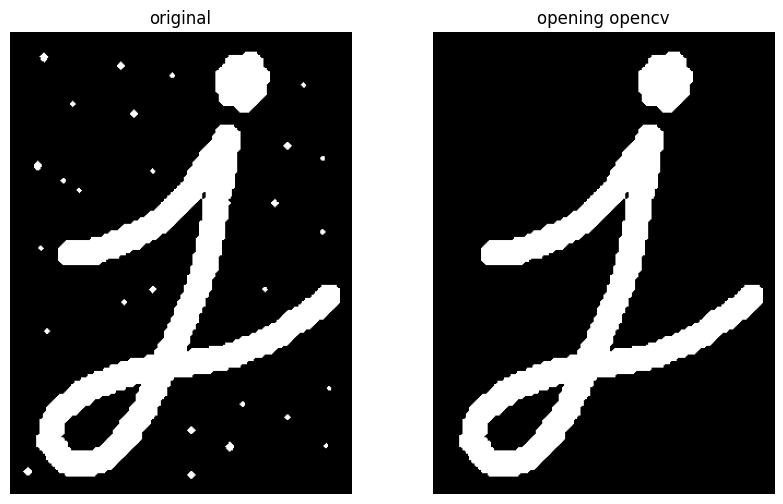

In [20]:
im_j = cv2.imread("j_opening.png", 0)
_, im_j = cv2.threshold(im_j, 127, 255, cv2.THRESH_BINARY)
kernel = np.ones((7, 7), np.uint8)

opening_j = cv2.morphologyEx(im_j, cv2.MORPH_OPEN, kernel)
plot_comparison(im_j, opening_j, "opening opencv")

### Closing

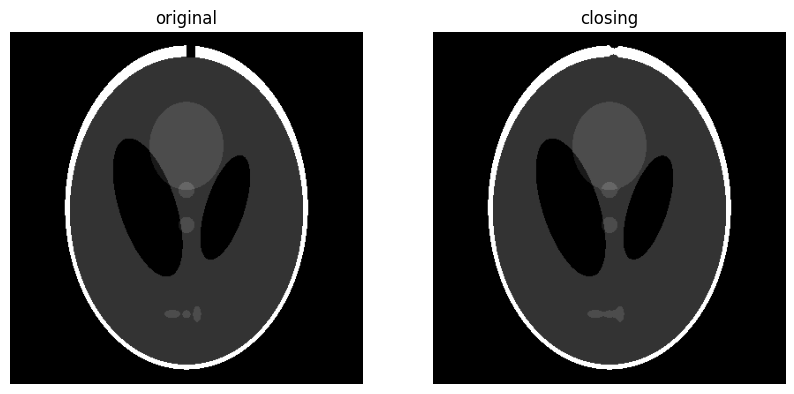

In [21]:
phantom = orig_phantom.copy()
phantom[10:30, 200:210] = 0

closed = closing(phantom, selem)
plot_comparison(phantom, closed, "closing")

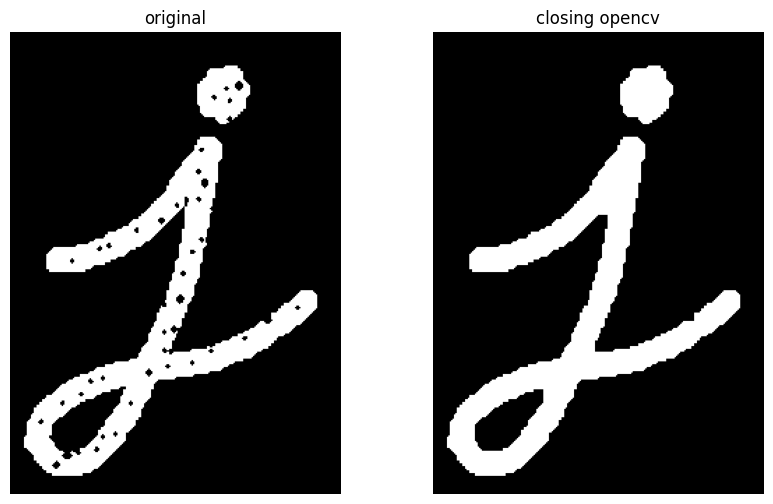

In [22]:
im_j = cv2.imread("j_closing.png", 0)
_, im_j = cv2.threshold(im_j, 127, 255, cv2.THRESH_BINARY)
kernel = np.ones((7, 7), np.uint8)

closing_j = cv2.morphologyEx(im_j, cv2.MORPH_CLOSE, kernel)
plot_comparison(im_j, closing_j, "closing opencv")

### Morphological gradient

Diff of dilation and errosion

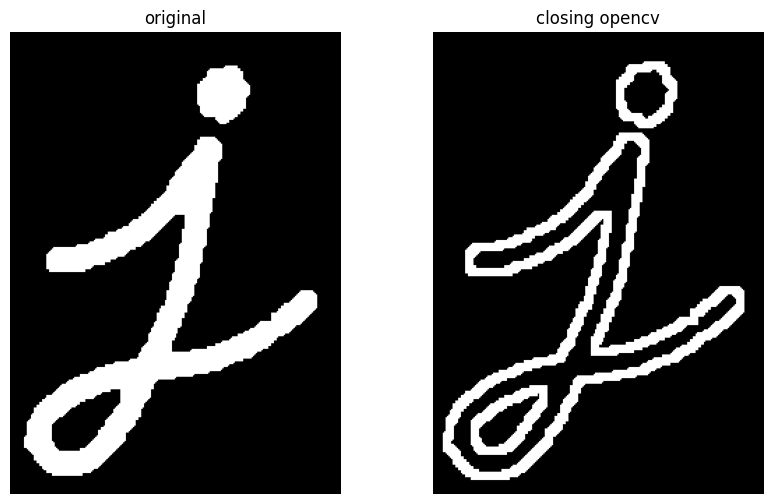

In [23]:
gradient = cv2.morphologyEx(closing_j, cv2.MORPH_GRADIENT, kernel)

plot_comparison(closing_j, gradient, "closing opencv")

### Tophat (white tophat)

image - opening. Highlights bright dots of an image which are smaller than struct element

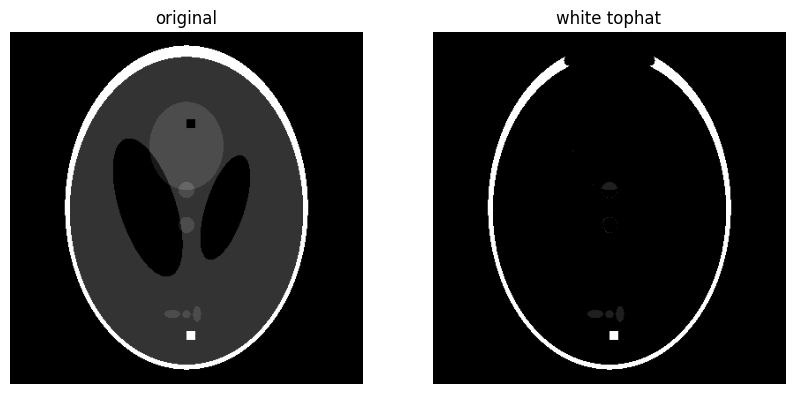

In [24]:
phantom = orig_phantom.copy()
phantom[340:350, 200:210] = 255
phantom[100:110, 200:210] = 0

w_tophat = white_tophat(phantom, selem)
plot_comparison(phantom, w_tophat, "white tophat")

We can remove small objects on image.

In [25]:
image = color.rgb2gray(data.hubble_deep_field())[:500, :500]

selem_th = disk(2)
res = white_tophat(image, selem_th)

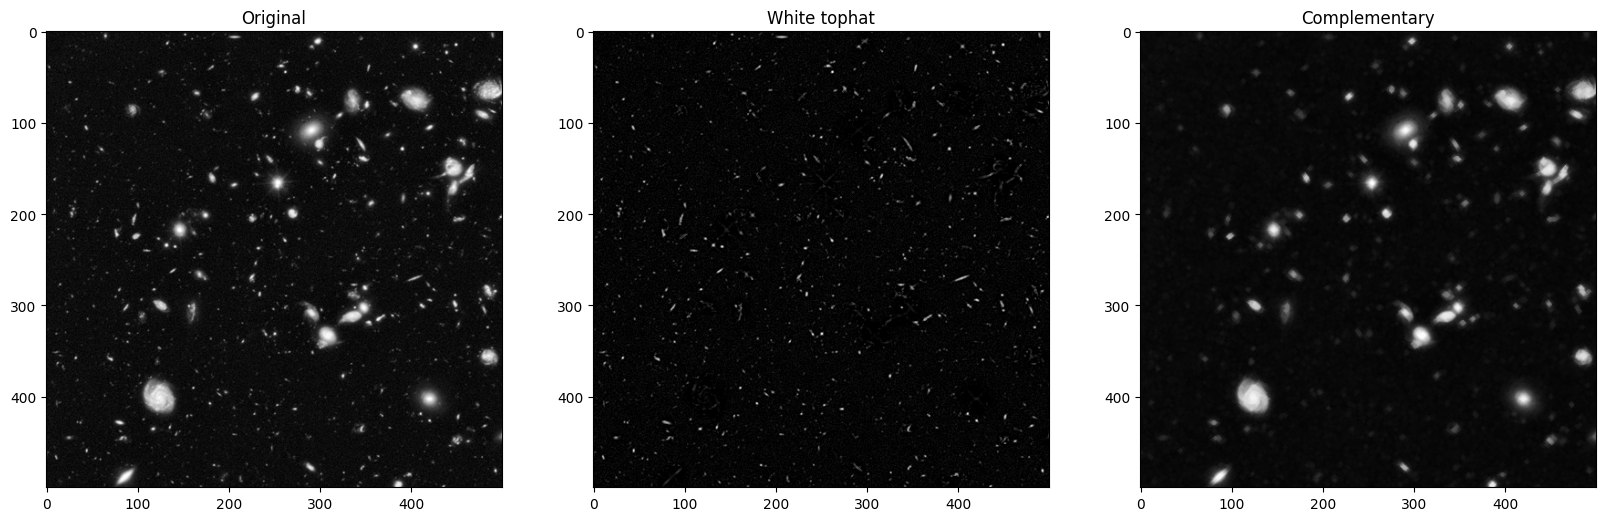

In [26]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))
ax[0].set_title("Original")
ax[0].imshow(image, cmap="gray")
ax[1].set_title("White tophat")
ax[1].imshow(res, cmap="gray")
ax[2].set_title("Complementary")
ax[2].imshow(image - res, cmap="gray")

plt.show()

### Black (top)hat

opening - image

Shows black dots

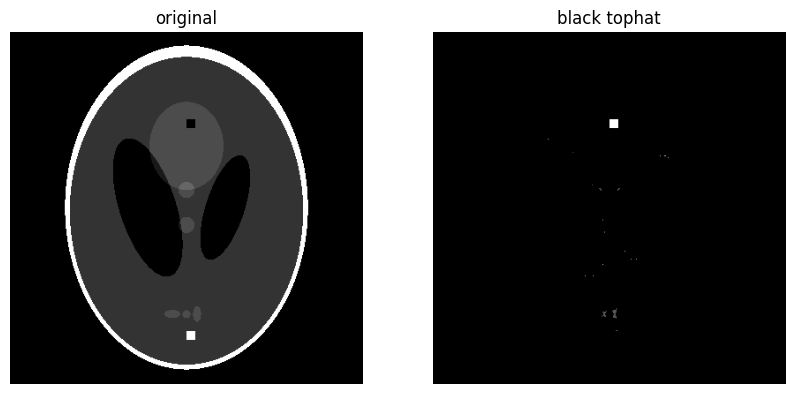

In [27]:
b_tophat = black_tophat(phantom, selem)
plot_comparison(phantom, b_tophat, "black tophat")

In [28]:
import matplotlib.pyplot as plt

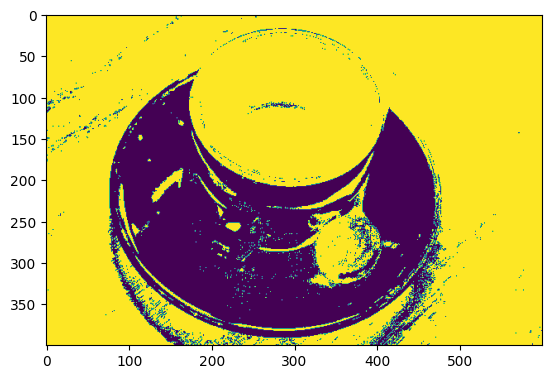

In [29]:
plt.imshow(binary_img)

### Skeletonization

[skimage doc](https://scikit-image.org/docs/stable/auto_examples/edges/plot_skeleton.html)

[Fierce heuristic](https://github.com/linbojin/Skeletonization-by-Zhang-Suen-Thinning-Algorithm)

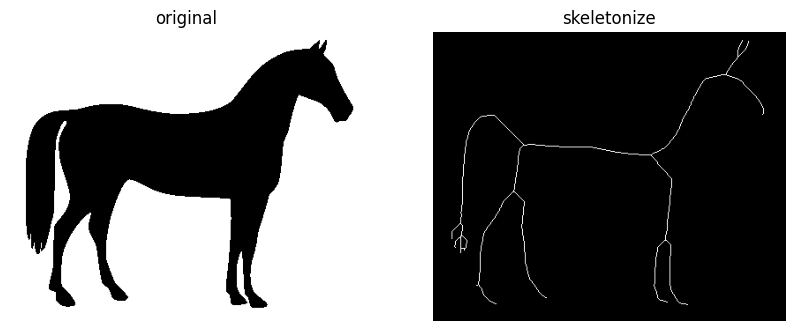

In [30]:
horse = data.horse()

sk = skeletonize(horse == 0)
plot_comparison(horse, sk, "skeletonize")

In [31]:
blobs = data.binary_blobs(200, blob_size_fraction=0.2, volume_fraction=0.35, seed=1)

skeleton = skeletonize(blobs)
skeleton_lee = skeletonize(blobs, method="lee")

/var/folders/cx/c_0x0d9s0ws_txrc3zdtxfq1lnj83m/T/ipykernel_84628/1480188769.py:1: FutureWarning: `seed` is a deprecated argument name for `binary_blobs`. It will be removed in version 0.23. Please use `rng` instead.
  blobs = data.binary_blobs(200, blob_size_fraction=0.2, volume_fraction=0.35, seed=1)


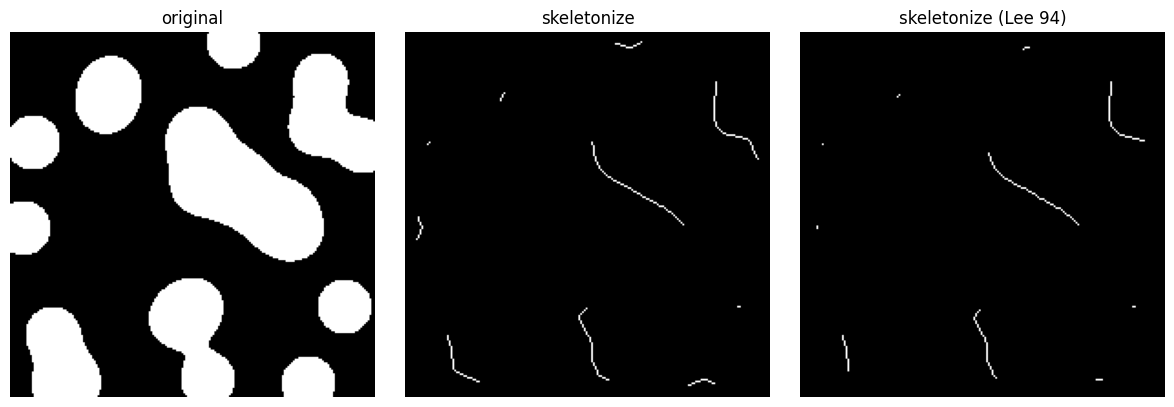

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(blobs, cmap=plt.cm.gray)
ax[0].set_title("original")
ax[0].axis("off")

ax[1].imshow(skeleton, cmap=plt.cm.gray)
ax[1].set_title("skeletonize")
ax[1].axis("off")

ax[2].imshow(skeleton_lee, cmap=plt.cm.gray)
ax[2].set_title("skeletonize (Lee 94)")
ax[2].axis("off")

fig.tight_layout()
plt.show()

In [33]:
# Generate the data
blobs = data.binary_blobs(200, blob_size_fraction=0.2, volume_fraction=0.35, seed=1)

# Compute the medial axis (skeleton) and the distance transform
skel, distance = medial_axis(blobs, return_distance=True)

# Compare with other skeletonization algorithms
skeleton = skeletonize(blobs)
skeleton_lee = skeletonize(blobs, method="lee")

# Distance to the background for pixels of the skeleton
dist_on_skel = distance * skel

/var/folders/cx/c_0x0d9s0ws_txrc3zdtxfq1lnj83m/T/ipykernel_84628/901860542.py:2: FutureWarning: `seed` is a deprecated argument name for `binary_blobs`. It will be removed in version 0.23. Please use `rng` instead.
  blobs = data.binary_blobs(200, blob_size_fraction=0.2, volume_fraction=0.35, seed=1)


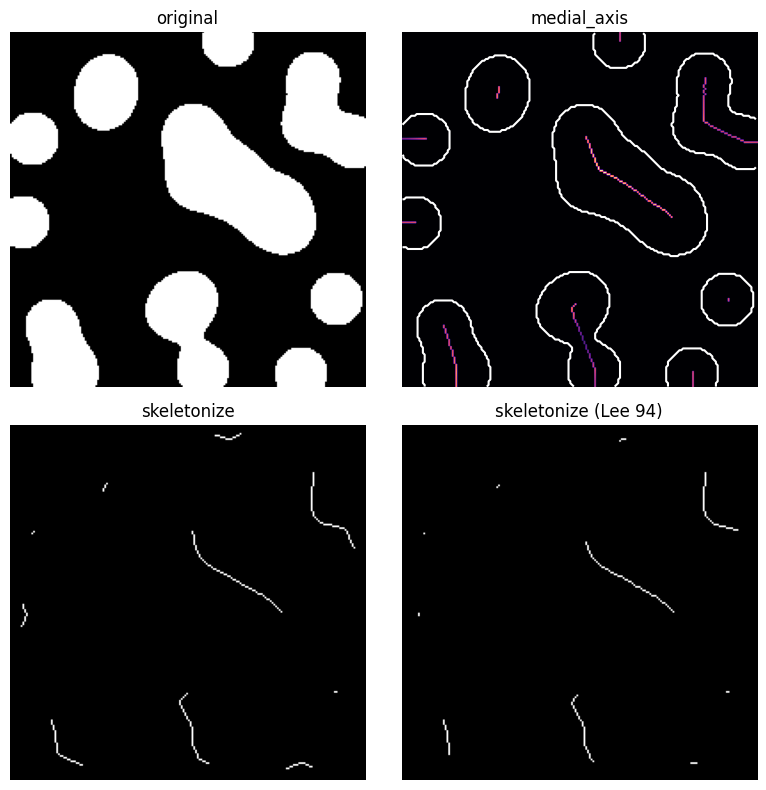

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(blobs, cmap=plt.cm.gray)
ax[0].set_title("original")
ax[0].axis("off")

ax[1].imshow(dist_on_skel, cmap="magma")
ax[1].contour(blobs, [0.5], colors="w")
ax[1].set_title("medial_axis")
ax[1].axis("off")

ax[2].imshow(skeleton, cmap=plt.cm.gray)
ax[2].set_title("skeletonize")
ax[2].axis("off")

ax[3].imshow(skeleton_lee, cmap=plt.cm.gray)
ax[3].set_title("skeletonize (Lee 94)")
ax[3].axis("off")

fig.tight_layout()
plt.show()

### Morphological thinning

[skimage doc](https://scikit-image.org/docs/stable/api/skimage.morphology.html#skimage.morphology.thin)

In [36]:
image = invert(data.horse())
skeleton = skeletonize(image)
thinned = thin(image)
thinned_partial = thin(image, max_num_iter=25)

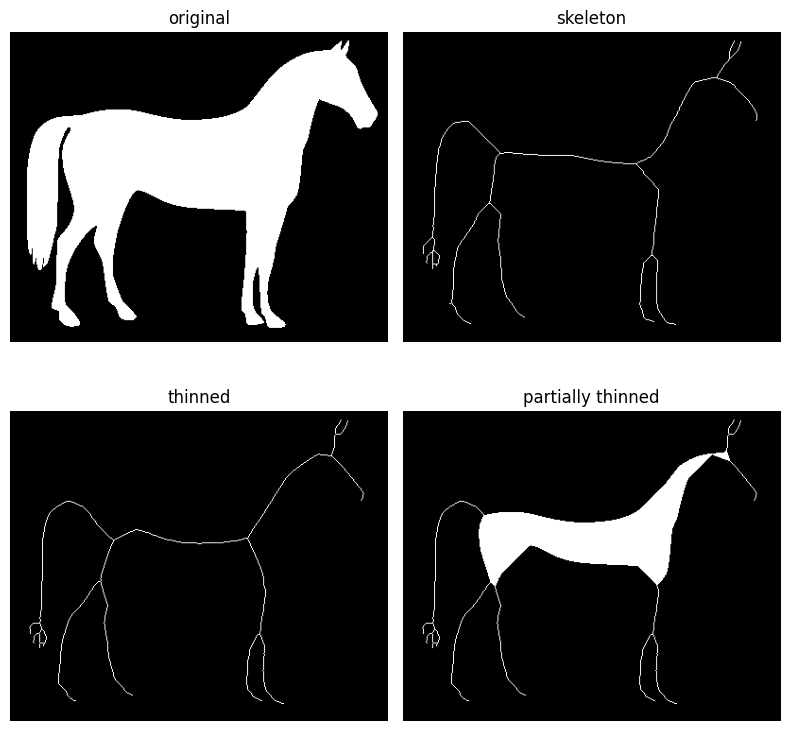

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("original")
ax[0].axis("off")

ax[1].imshow(skeleton, cmap=plt.cm.gray)
ax[1].set_title("skeleton")
ax[1].axis("off")

ax[2].imshow(thinned, cmap=plt.cm.gray)
ax[2].set_title("thinned")
ax[2].axis("off")

ax[3].imshow(thinned_partial, cmap=plt.cm.gray)
ax[3].set_title("partially thinned")
ax[3].axis("off")

fig.tight_layout()
plt.show()

### Convex hull

[skimage doc](https://scikit-image.org/docs/stable/auto_examples/edges/plot_convex_hull.html)

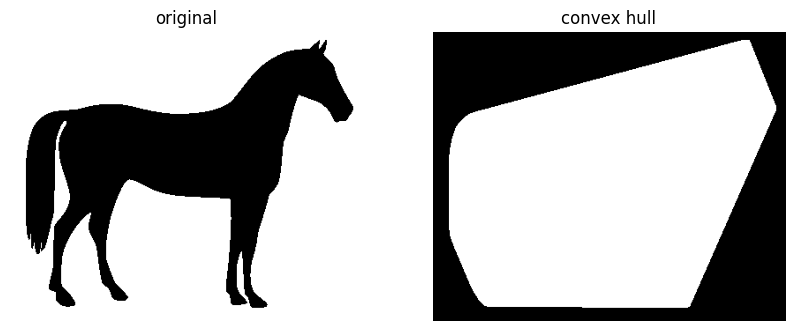

In [38]:
horse = data.horse()
hull1 = convex_hull_image(horse == 0)
plot_comparison(horse, hull1, "convex hull")

if we add small white dot, convex hull will change, so it's important to clear image before this operation

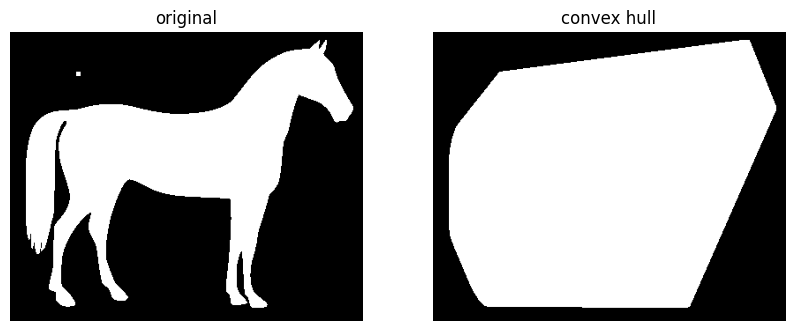

In [39]:
horse_mask = horse == 0
horse_mask[45:50, 75:80] = 1

hull2 = convex_hull_image(horse_mask)
plot_comparison(horse_mask, hull2, "convex hull")

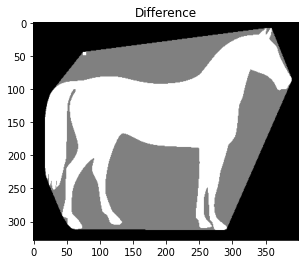

In [33]:
hull_diff = img_as_float(hull2.copy())
hull_diff[horse_mask] = 2

fig, ax = plt.subplots()
ax.imshow(hull_diff, cmap=plt.cm.gray)
ax.set_title("Difference")
plt.show()

## Simple segmentation

### Canny Edge Detection 

[opencv doc](https://docs.opencv.org/4.8.0/da/d22/tutorial_py_canny.html)

[Great ridges and edges overview](https://dsp.stackexchange.com/questions/1714/best-way-of-segmenting-veins-in-leaves)

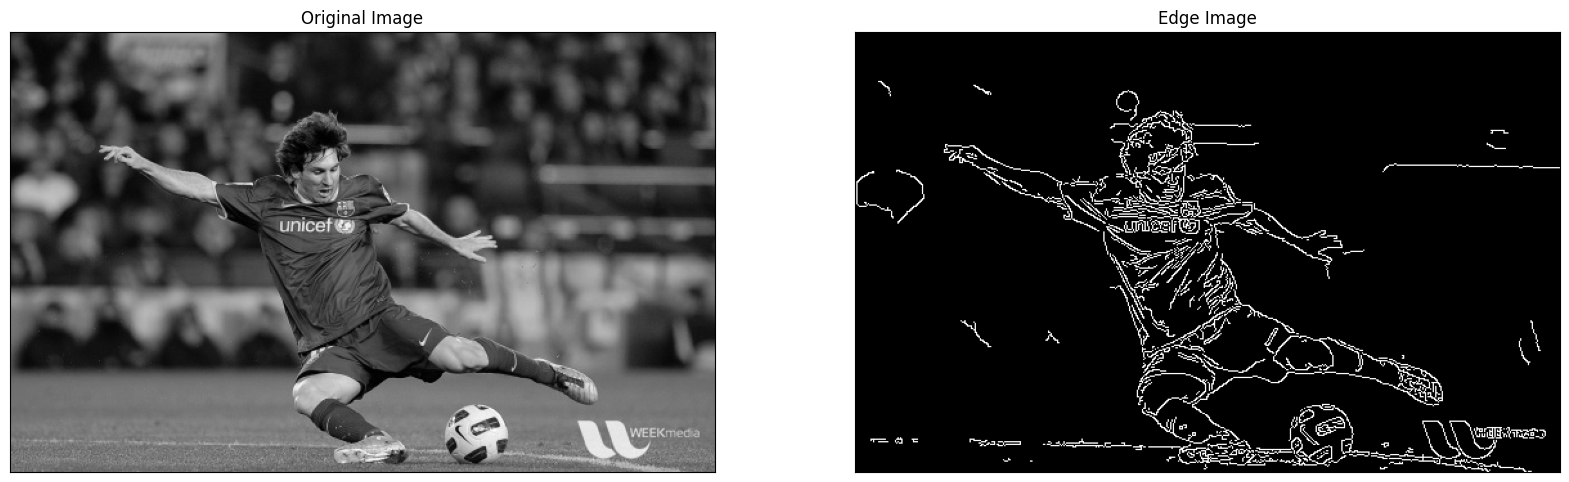

In [40]:
img = cv2.imread("messi.jpg", 0)
edges = cv2.Canny(img, 100, 200)

fig, ax = plt.subplots(ncols=2, figsize=(20, 8))
plt.subplot(121), plt.imshow(img, cmap="gray")
plt.title("Original Image"), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(edges, cmap="gray")
plt.title("Edge Image"), plt.xticks([]), plt.yticks([])
plt.show()

Also available in skimage

In [41]:
im = np.zeros((128, 128))
im[32:-32, 32:-32] = 1

im = ndi.rotate(im, 15, mode="constant")
im = ndi.gaussian_filter(im, 4)
im += 0.2 * np.random.random(im.shape)

Let's try different thresholds

In [42]:
edges1 = feature.canny(im)
edges2 = feature.canny(im, sigma=3)

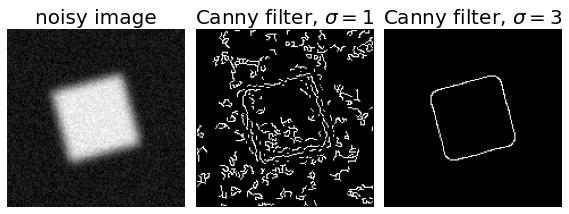

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(8, 3), sharex=True, sharey=True)

ax1.imshow(im, cmap=plt.cm.gray)
ax1.axis("off")
ax1.set_title("noisy image", fontsize=20)

ax2.imshow(edges1, cmap=plt.cm.gray)
ax2.axis("off")
ax2.set_title(r"Canny filter, $\sigma=1$", fontsize=20)

ax3.imshow(edges2, cmap=plt.cm.gray)
ax3.axis("off")
ax3.set_title(r"Canny filter, $\sigma=3$", fontsize=20)

fig.tight_layout()

plt.show()

### Circular Hough Transform

[Wiki on lines detection](https://en.wikipedia.org/wiki/Hough_transform)

[skimage linear doc](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)

[skimage circular doc](https://scikit-image.org/docs/stable/auto_examples/edges/plot_circular_elliptical_hough_transform.html)

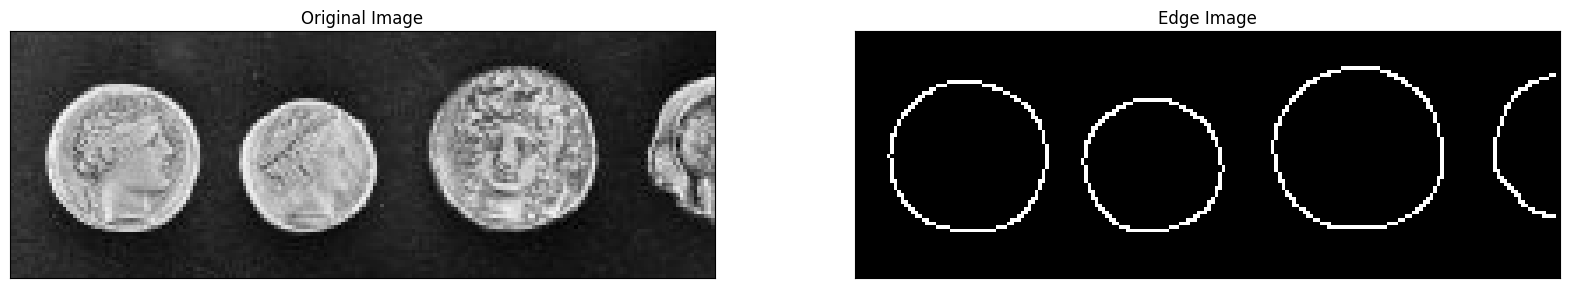

In [43]:
# Load picture and detect edges
image = img_as_ubyte(data.coins()[160:230, 70:270])
edges = canny(image, sigma=3, low_threshold=10, high_threshold=50)

fig, ax = plt.subplots(ncols=2, figsize=(20, 8))
plt.subplot(121), plt.imshow(image, cmap="gray")
plt.title("Original Image"), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(edges, cmap="gray")
plt.title("Edge Image"), plt.xticks([]), plt.yticks([])
plt.show()

In [44]:
# Detect two radii
hough_radii = np.arange(20, 35, 2)
hough_res = hough_circle(edges, hough_radii)

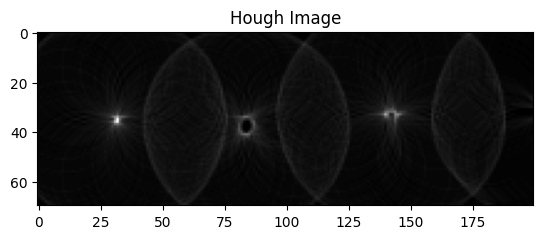

In [45]:
plt.imshow(hough_res[1], cmap="gray")
plt.title("Hough Image")
plt.show()

In [46]:
# Select the most prominent 3 circles
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=3)

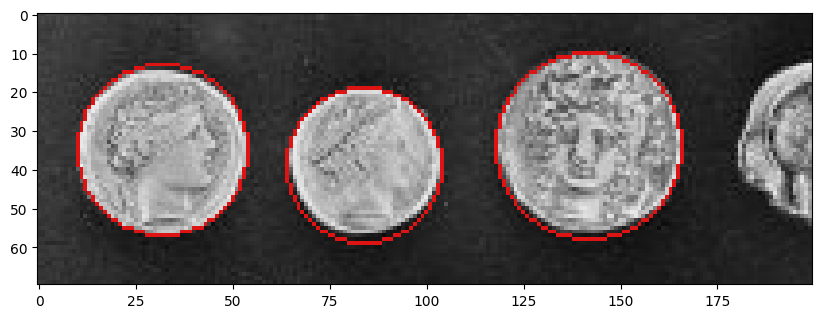

In [47]:
# Draw them
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 4))
image = color.gray2rgb(image)
for center_y, center_x, radius in zip(cy, cx, radii):
    circy, circx = circle_perimeter(center_y, center_x, radius, shape=image.shape)
    image[circy, circx] = (220, 20, 20)

ax.imshow(image, cmap=plt.cm.gray)
plt.show()

In [48]:
cx, cy, radii

(array([ 32, 142,  84]), array([35, 34, 39]), array([22, 24, 20]))

### Elliptical forms

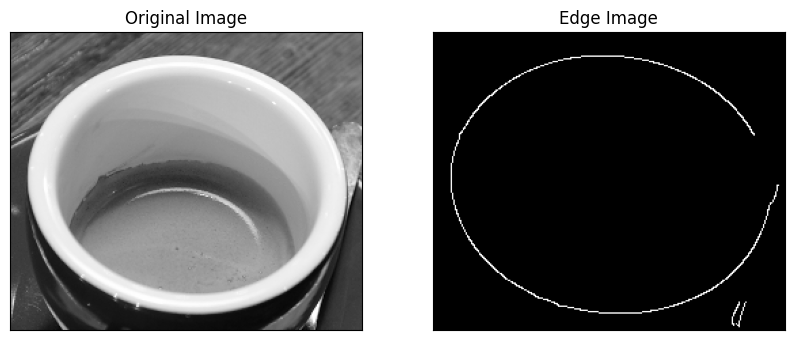

In [49]:
# Load picture, convert to grayscale and detect edges
image_rgb = data.coffee()[0:220, 160:420]
image_gray = color.rgb2gray(image_rgb)
edges = canny(image_gray, sigma=2.0, low_threshold=0.55, high_threshold=0.8)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
plt.subplot(121), plt.imshow(image_gray, cmap="gray")
plt.title("Original Image"), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(edges, cmap="gray")
plt.title("Edge Image"), plt.xticks([]), plt.yticks([])
plt.show()

In [50]:
# Perform a Hough Transform
# The accuracy corresponds to the bin size of a major axis.
# The value is chosen in order to get a single high accumulator.
# The threshold eliminates low accumulators
result = hough_ellipse(edges, accuracy=20, threshold=250, min_size=100, max_size=120)
result.sort(order="accumulator")

# Estimated parameters for the ellipse
best = list(result[-1])
yc, xc, a, b = [int(round(x)) for x in best[1:5]]
orientation = best[5]

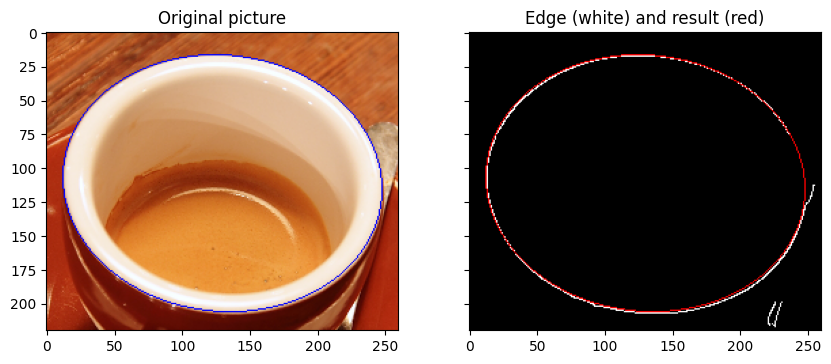

In [51]:
# Draw the ellipse on the original image
cy, cx = ellipse_perimeter(yc, xc, a, b, orientation)
image_rgb[cy, cx] = (0, 0, 255)
# Draw the edge (white) and the resulting ellipse (red)
edges = color.gray2rgb(img_as_ubyte(edges))
edges[cy, cx] = (250, 0, 0)

fig2, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 4), sharex=True, sharey=True)

ax1.set_title("Original picture")
ax1.imshow(image_rgb)

ax2.set_title("Edge (white) and result (red)")
ax2.imshow(edges)

plt.show()

#### Hough in OpenCV

In [52]:
img = img_as_ubyte(data.coins()[160:230, 70:270])
cimg = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(
    img, cv2.HOUGH_GRADIENT, 1, 30, param1=65, param2=40, minRadius=10, maxRadius=35
)
circles = np.uint16(np.around(circles))

for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(cimg, (i[0], i[1]), i[2], (0, 255, 0), 2)
    # draw the center of the circle
    cv2.circle(cimg, (i[0], i[1]), 2, (0, 0, 255), 3)

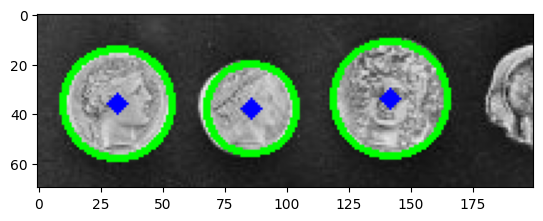

In [53]:
plt.imshow(cimg)

### Watershed segmentation

https://img-blog.csdnimg.cn/20190315153313192.png

[skimage doc](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_watershed.html)

[opencv doc](https://docs.opencv.org/4.8.0/d3/db4/tutorial_py_watershed.html)

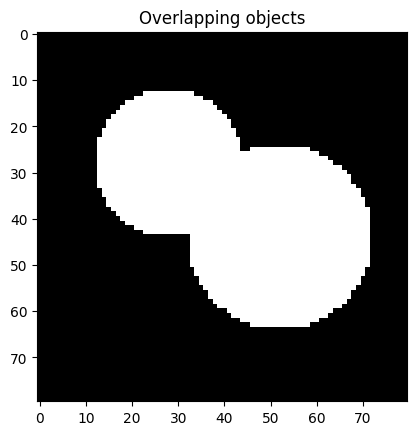

In [54]:
x, y = np.indices((80, 80))
x1, y1, x2, y2 = 28, 28, 44, 52
r1, r2 = 16, 20
mask_circle1 = (x - x1) ** 2 + (y - y1) ** 2 < r1**2
mask_circle2 = (x - x2) ** 2 + (y - y2) ** 2 < r2**2
image = np.logical_or(mask_circle1, mask_circle2)

plt.imshow(image, cmap=plt.cm.gray)
plt.title("Overlapping objects")
plt.show()

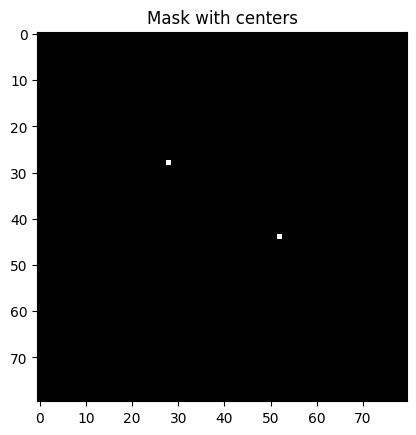

In [55]:
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=image)

mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True

plt.imshow(mask, cmap=plt.cm.gray)
plt.title("Mask with centers")
plt.show()

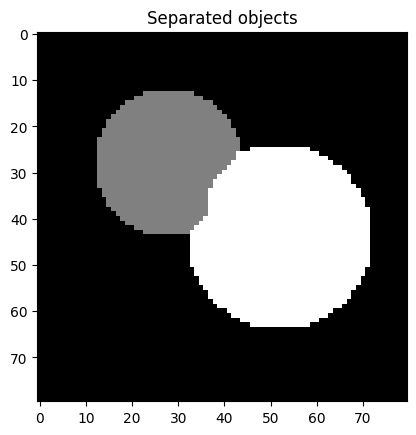

In [56]:
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

plt.imshow(labels, cmap=plt.cm.gray)
plt.title("Separated objects")
plt.show()

#### Watershed in OpenCV

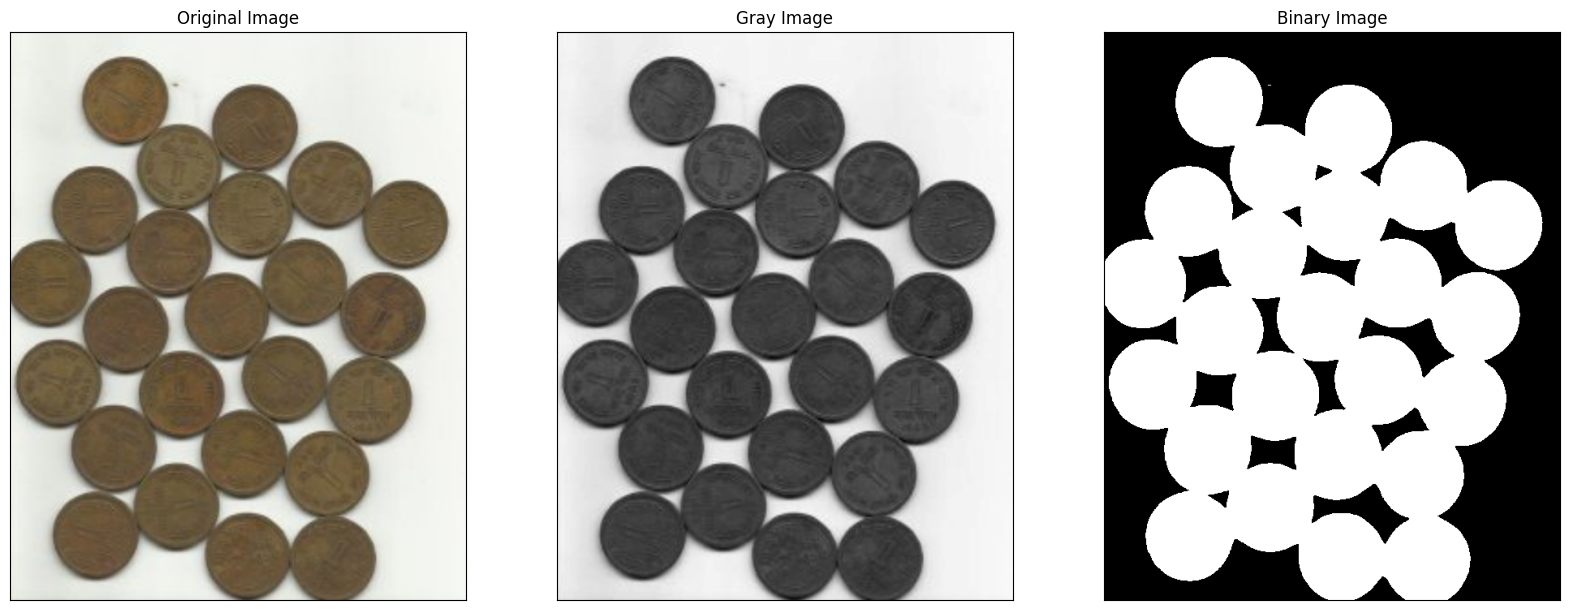

In [57]:
img = cv2.imread("coins.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

fig, ax = plt.subplots(ncols=3, figsize=(20, 8))
plt.subplot(131), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image"), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(gray, cmap="gray")
plt.title("Gray Image"), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(thresh, cmap="gray")
plt.title("Binary Image"), plt.xticks([]), plt.yticks([])
plt.show()

In [58]:
# noise removal
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

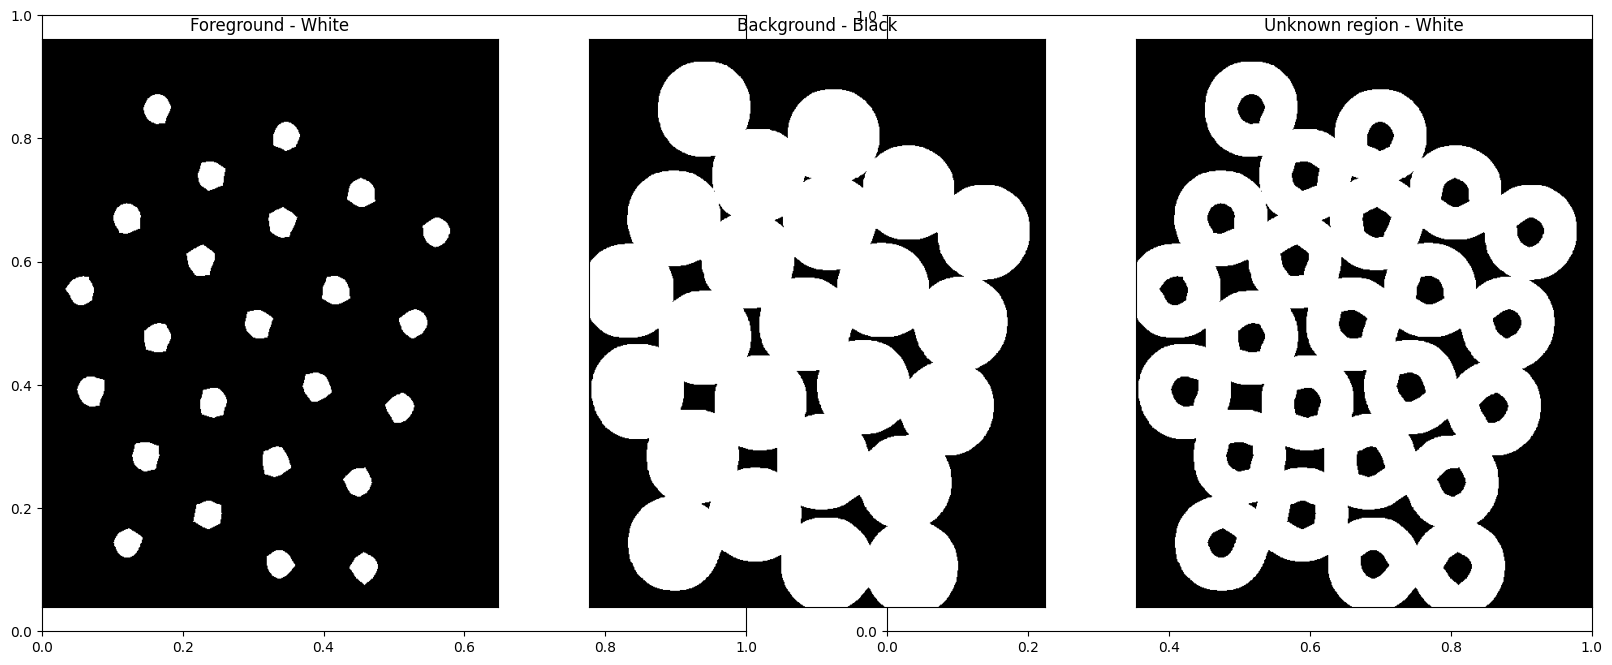

In [59]:
fig, ax = plt.subplots(ncols=2, figsize=(20, 8))
plt.subplot(131), plt.imshow(cv2.cvtColor(sure_fg, cv2.COLOR_BGR2RGB))
plt.title("Foreground - White"), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(sure_bg, cmap="gray")
plt.title("Background - Black"), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(unknown, cmap="gray")
plt.title("Unknown region - White"), plt.xticks([]), plt.yticks([])
plt.show()

In [60]:
# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1

# Now, mark the region of unknown with zero
markers[unknown == 255] = 0

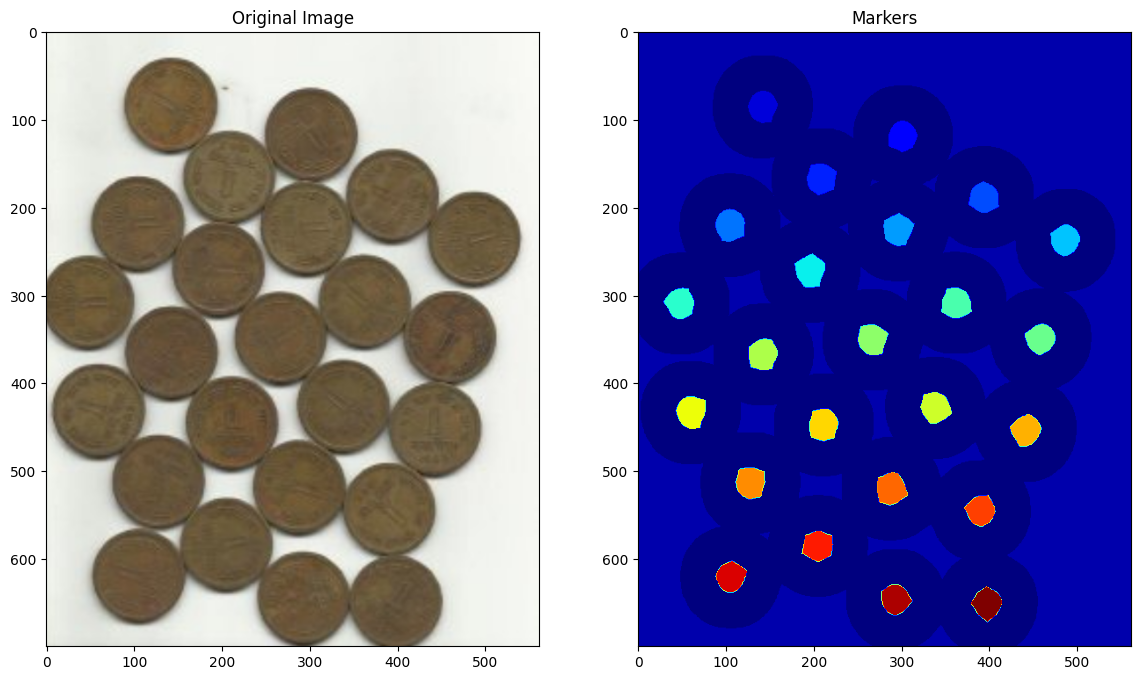

In [61]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 8))
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(122), plt.imshow(markers, cmap="jet")
plt.title("Markers")

plt.show()

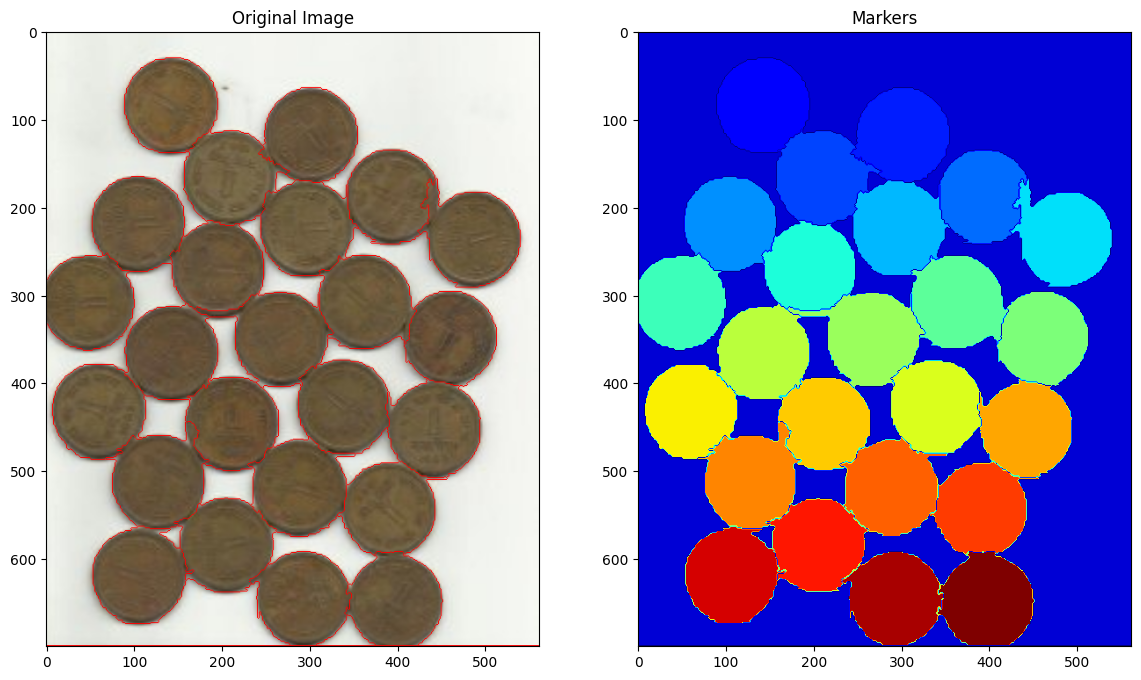

In [62]:
markers = cv2.watershed(img, markers)
img[markers == -1] = [0, 0, 255]

fig, ax = plt.subplots(ncols=2, figsize=(14, 8))
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(122), plt.imshow(markers, cmap="jet")
plt.title("Markers")

plt.show()

### Generic pipeline for segmentation

- setting threshold values for binarizatioin whith Otsu filter
- filling small noisy dots with morphological closing
- border artifacts (objects intersection) deletion
- filtering small objects by square

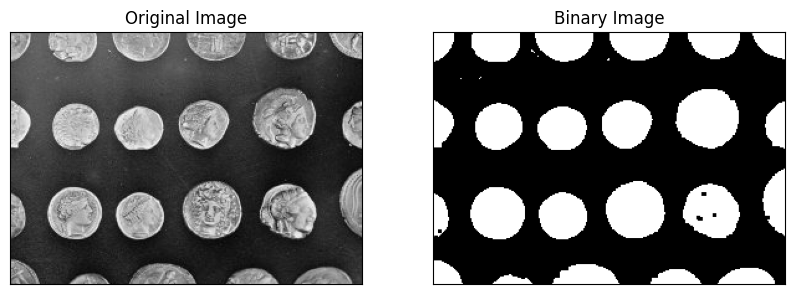

In [63]:
image = data.coins()[50:-50, 50:-50]

# apply threshold
thresh = threshold_otsu(image)
bw = closing(image > thresh, square(3))

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
plt.subplot(121), plt.imshow(image, cmap="gray")
plt.title("Original Image"), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(bw, cmap="gray")
plt.title("Binary Image"), plt.xticks([]), plt.yticks([])
plt.show()

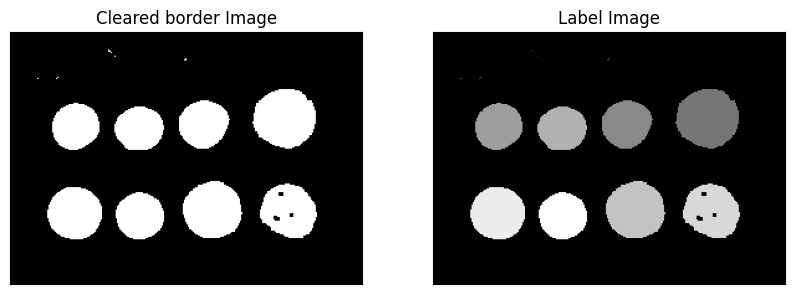

In [64]:
# remove artifacts connected to image border
cleared = clear_border(bw)

# label image regions
label_image = label(cleared)

# to make the background transparent, pass the value of `bg_label`,
# and leave `bg_color` as `None` and `kind` as `overlay`
image_label_overlay = label2rgb(label_image, image=image, bg_label=0)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
plt.subplot(121), plt.imshow(cleared, cmap="gray")
plt.title("Cleared border Image"), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(label_image, cmap="gray")
plt.title("Label Image"), plt.xticks([]), plt.yticks([])
plt.show()

Object 5: (46, 195, 94, 246)
Object 6: (55, 136, 94, 177)
Object 7: (57, 34, 95, 72)
Object 8: (60, 84, 95, 124)
Object 9: (120, 139, 166, 187)
Object 10: (122, 201, 166, 247)
Object 11: (125, 30, 167, 74)
Object 12: (129, 85, 167, 124)


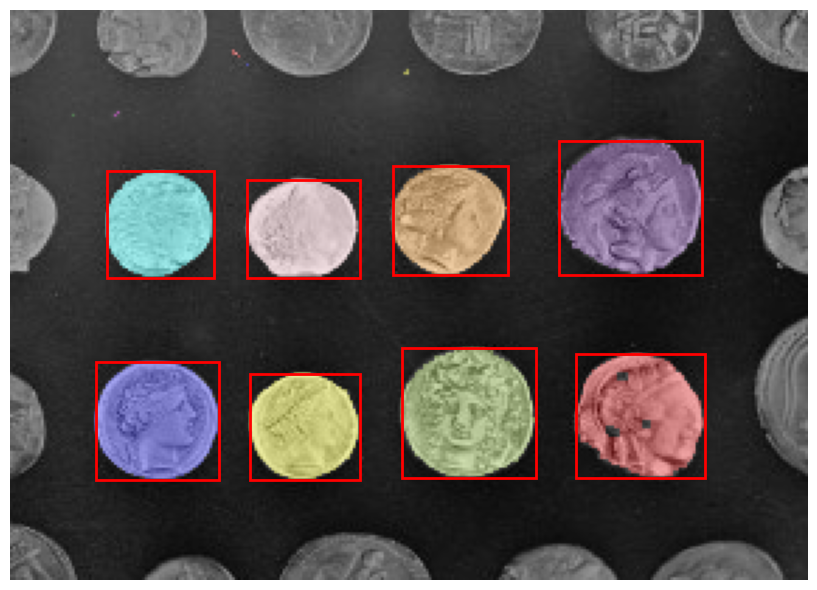

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image_label_overlay)

for i, region in enumerate(regionprops(label_image)):
    # take regions with large enough areas
    if region.area >= 100:
        print(f"Object {i}: {region.bbox}")
        # draw rectangle around segmented coins
        minr, minc, maxr, maxc = region.bbox
        rect = mpatches.Rectangle(
            (minc, minr), maxc - minc, maxr - minr, fill=False, edgecolor="red", linewidth=2
        )
        ax.add_patch(rect)

ax.set_axis_off()
plt.tight_layout()
plt.show()